In [ ]:
import numpy as np
import networkx as nx
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.graphs.utils import *
from src.hyperbolicity.gromov import *
from src.graphs.visualization import *

from collections import Counter
%load_ext autoreload
%autoreload 2
from src.optimization.solver import *
from src.optimization.objectives import *
import yaml
import random

In [3]:
def get_opt_pm():
    with open("../configs/optimization_parameters.yaml", "r") as file:
        config = yaml.safe_load(file)
    config = config['optimization']
    return config['temperature'],config['alpha_diffusion'],config['time'],config['localized_nodes'],config['lambda_reg']
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()

Is G connected? True
With this configuration we would like to work with [30] and distant sample: [54]


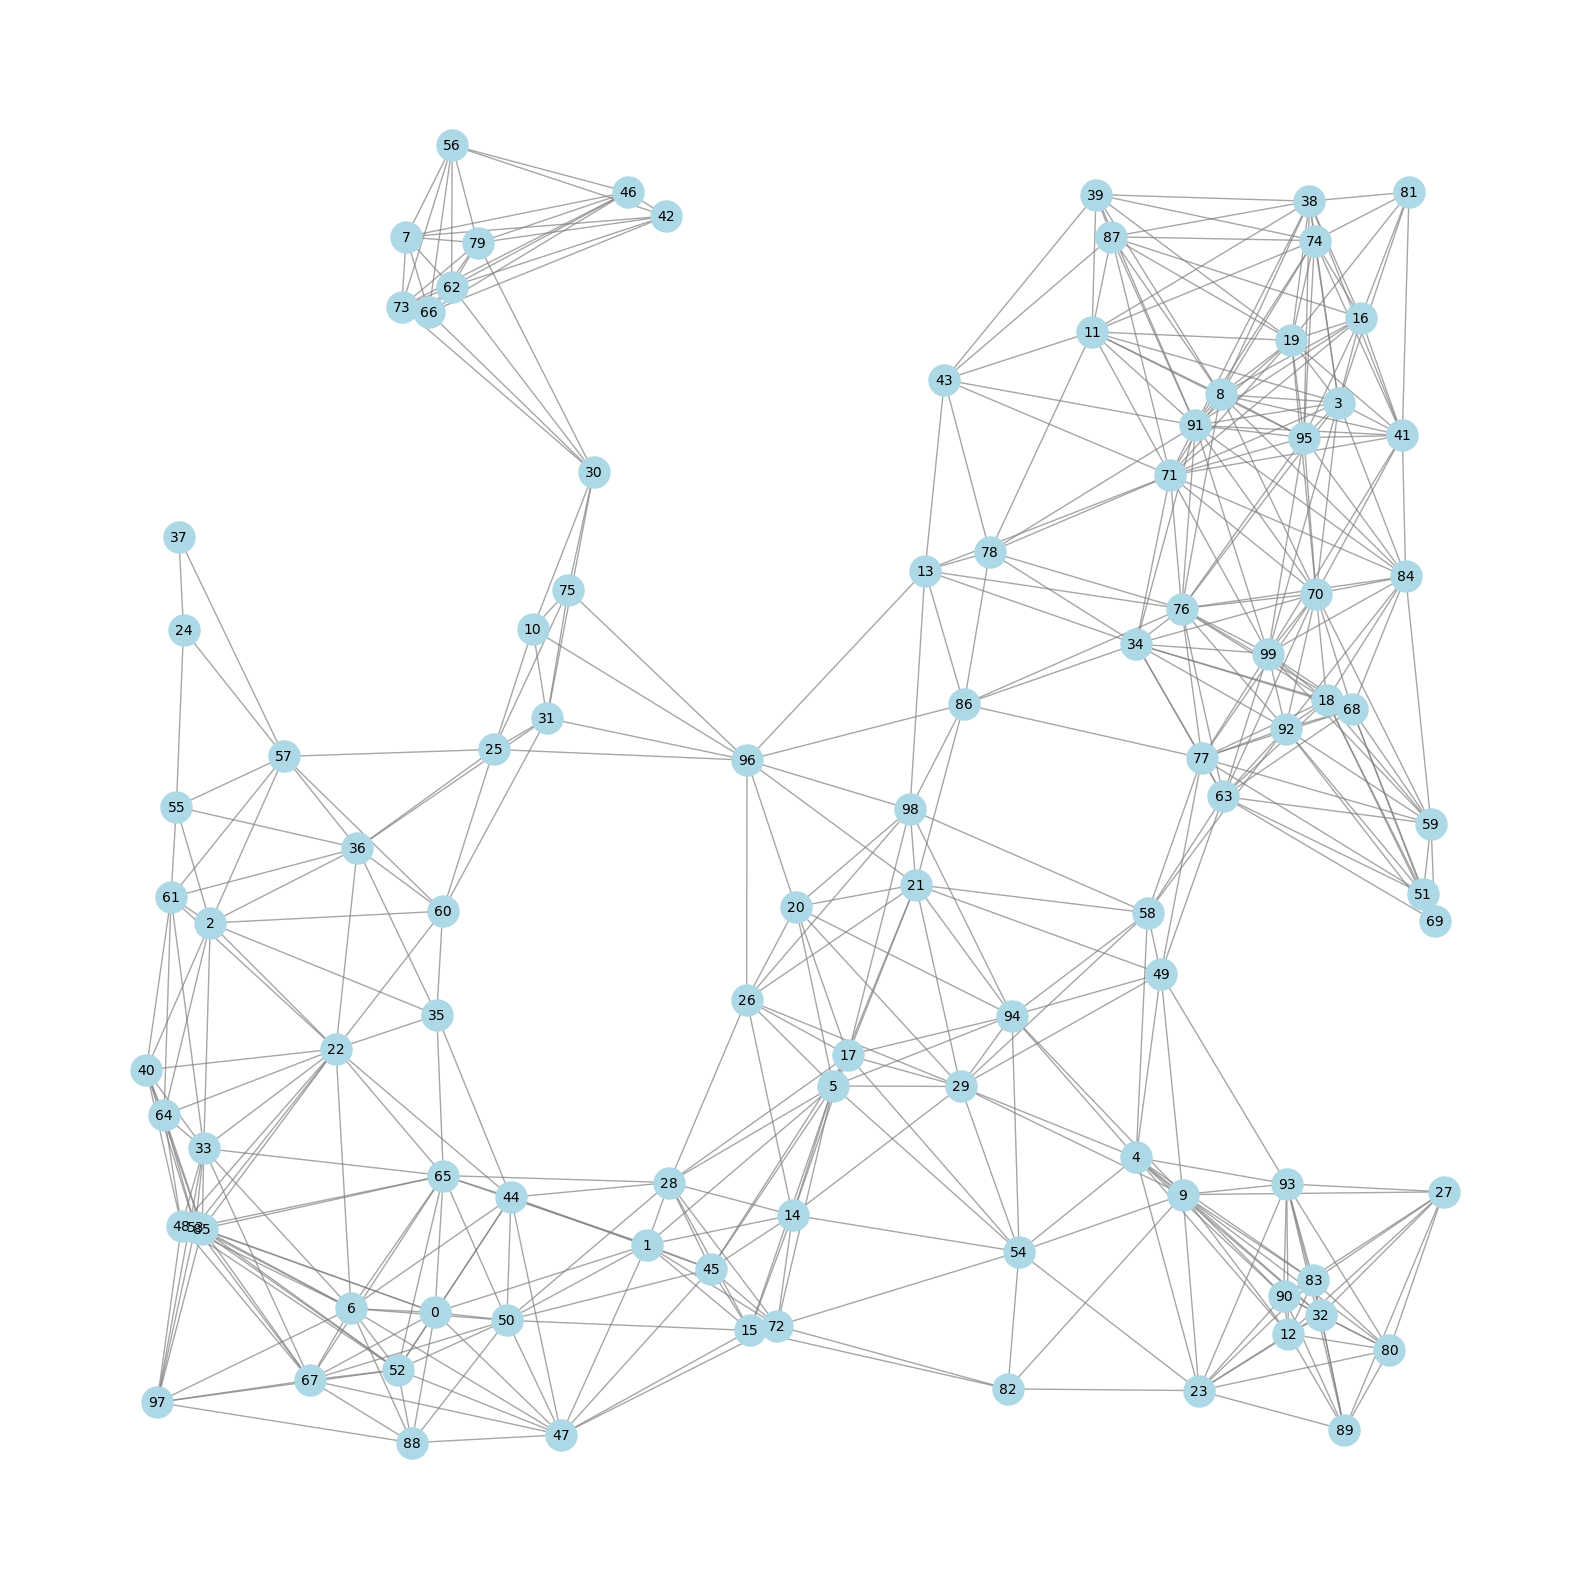

Counter({np.float64(0.0): 2060123, np.float64(0.5): 1341569, np.float64(1.0): 408656, np.float64(1.5): 101117, np.float64(2.0): 9246, np.float64(2.5): 514})


In [64]:
G = nx.random_geometric_graph(n=100, radius=0.2, seed=4)
pos = nx.get_node_attributes(G, 'pos')
print(f"Is G connected? {nx.is_connected(G)}")
localized_nodes = [30]
distant_test_nodes = [54]
print(f"With this configuration we would like to work with {localized_nodes} and distant sample: {distant_test_nodes}")
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
draw_graphs(G,pos, base_figsize=(16,16))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))


The localized nodes are: [30] and lambda is 2
The only data fidelity component mu times delta is: 0.5006885967336214
La cost function e' 0.10469519043992732 - -0.033033464895584924: 0.13772865533551223


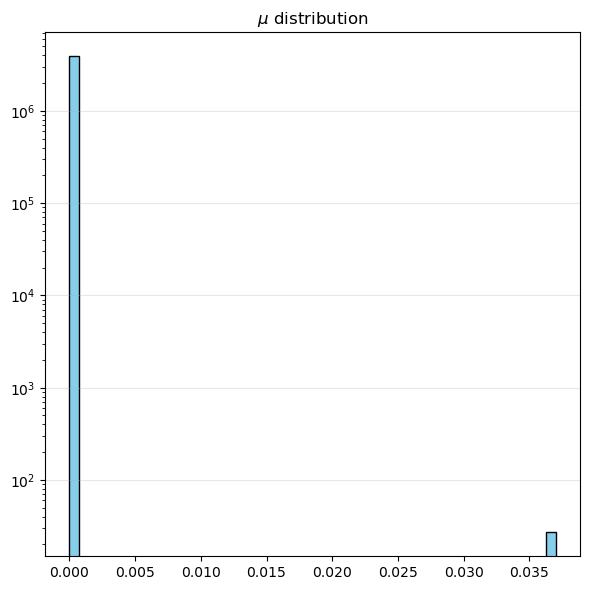

Too many quadruples to visualize (10), showing only the first 9.


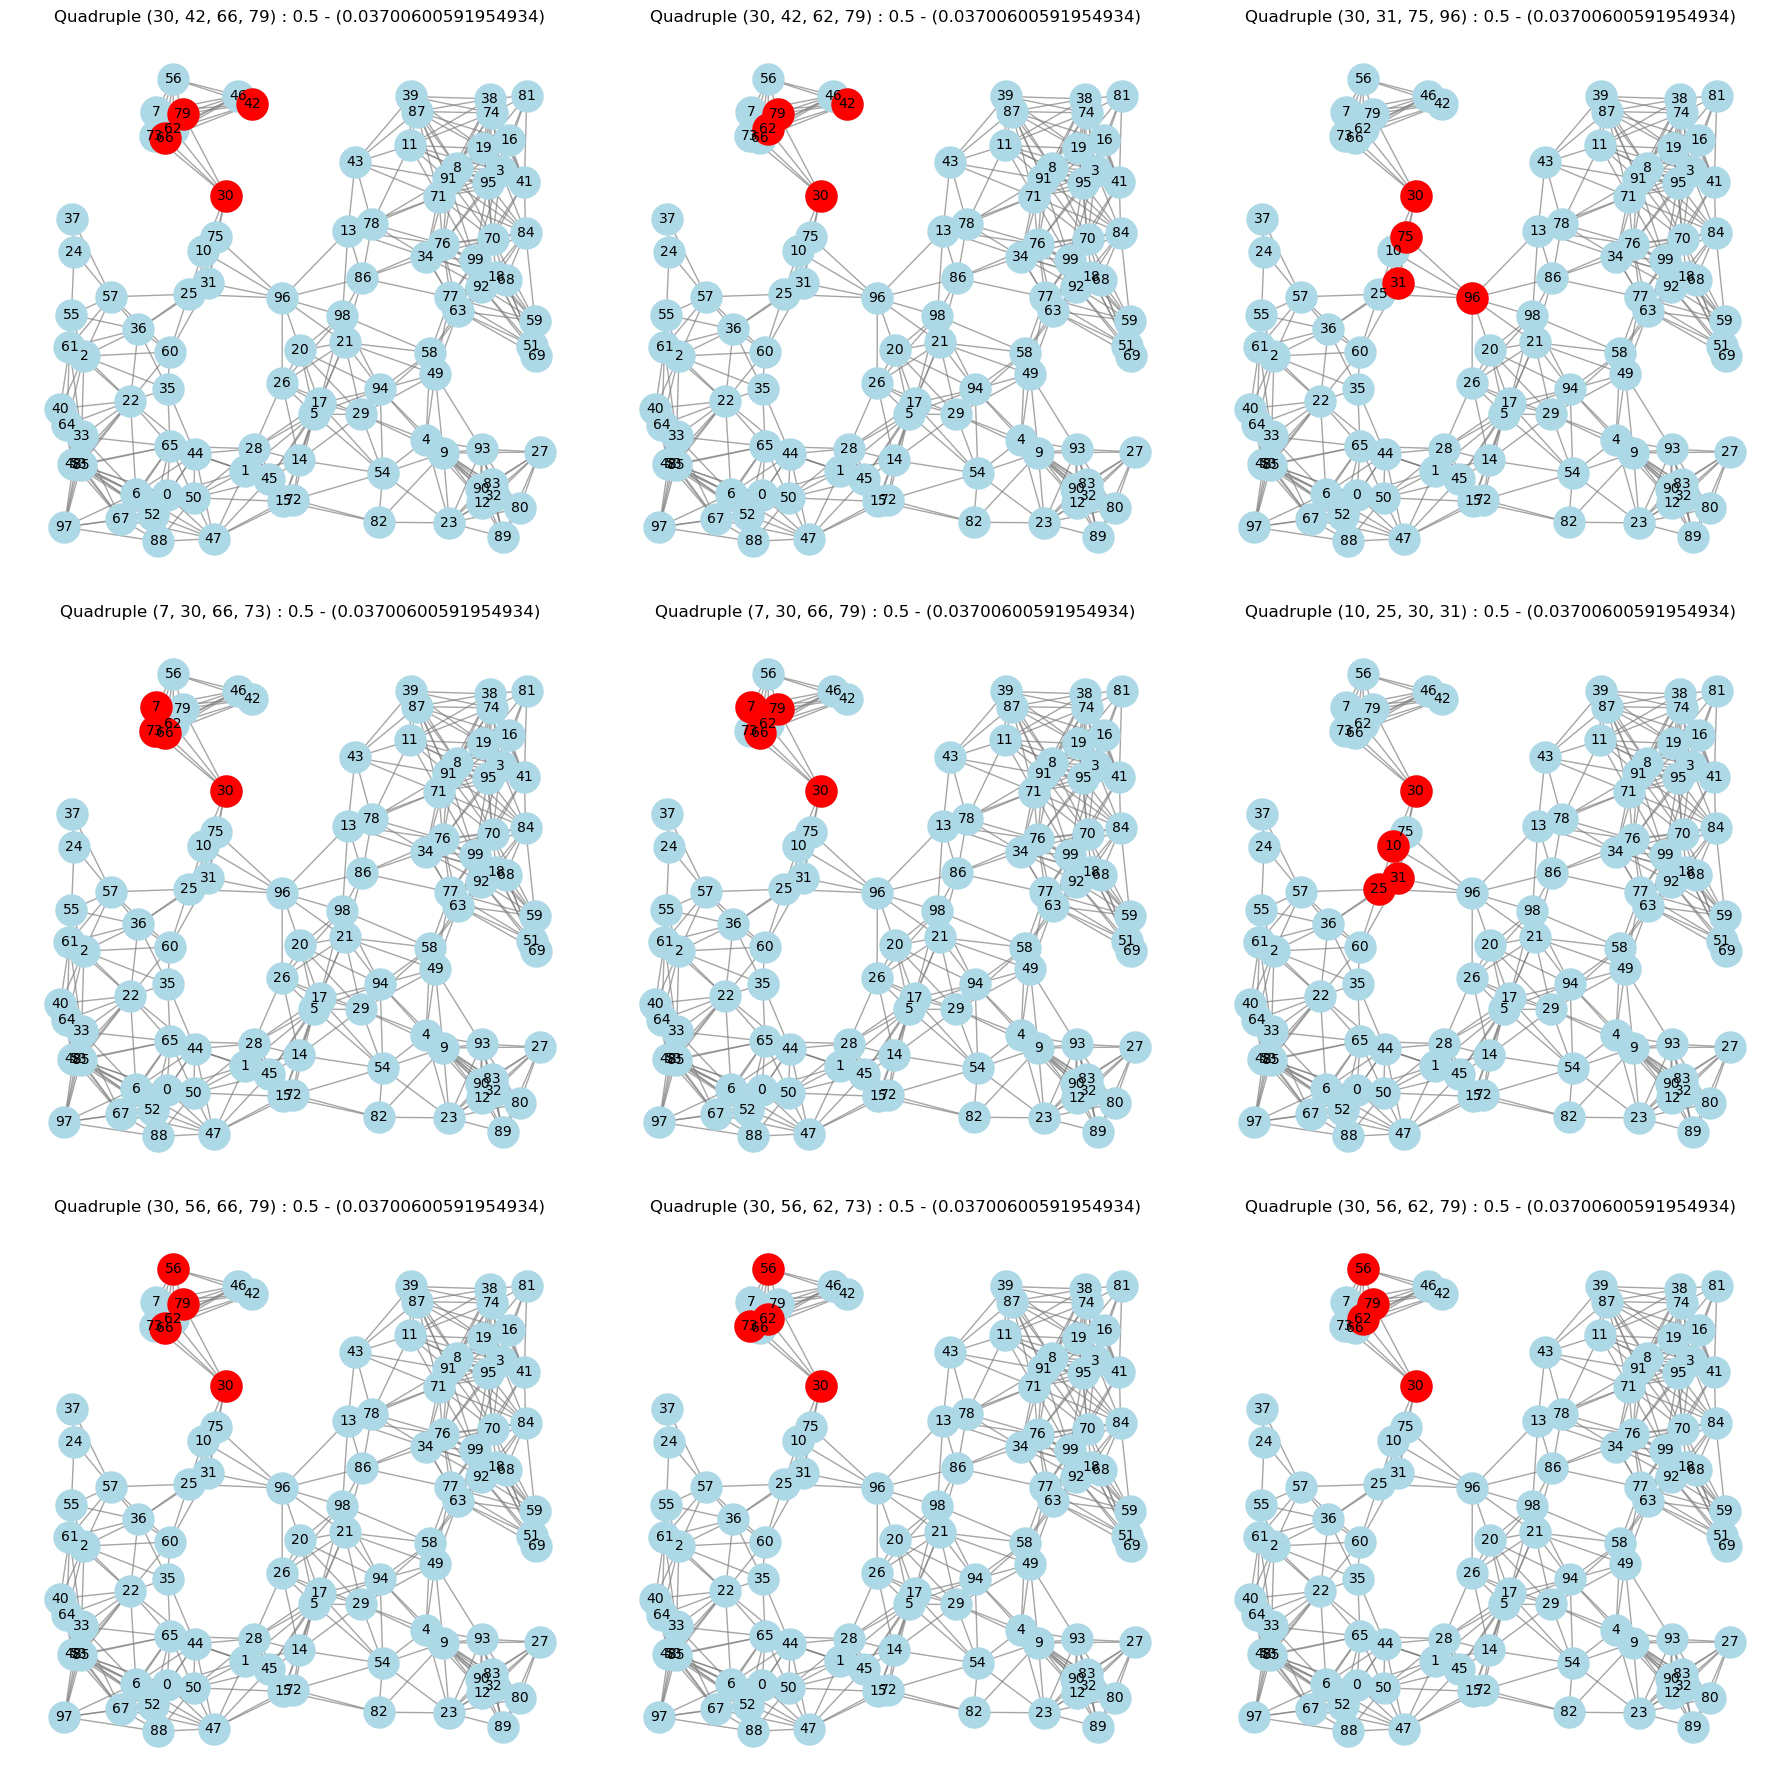

The distant sample nodes are: [54] and lambda is 2
The only data fidelity component mu times delta is: 2.4463561742252757
La cost function e' 0.3582745446462723 - -0.009055554509002584: 0.3673300991552749


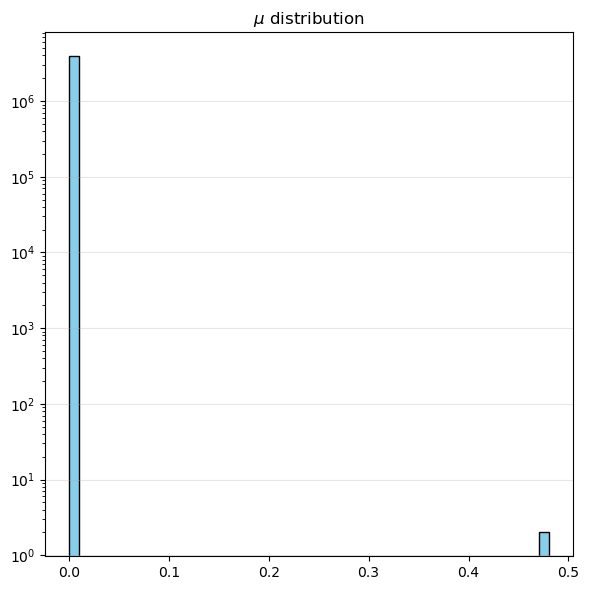

Too many quadruples to visualize (10), showing only the first 9.


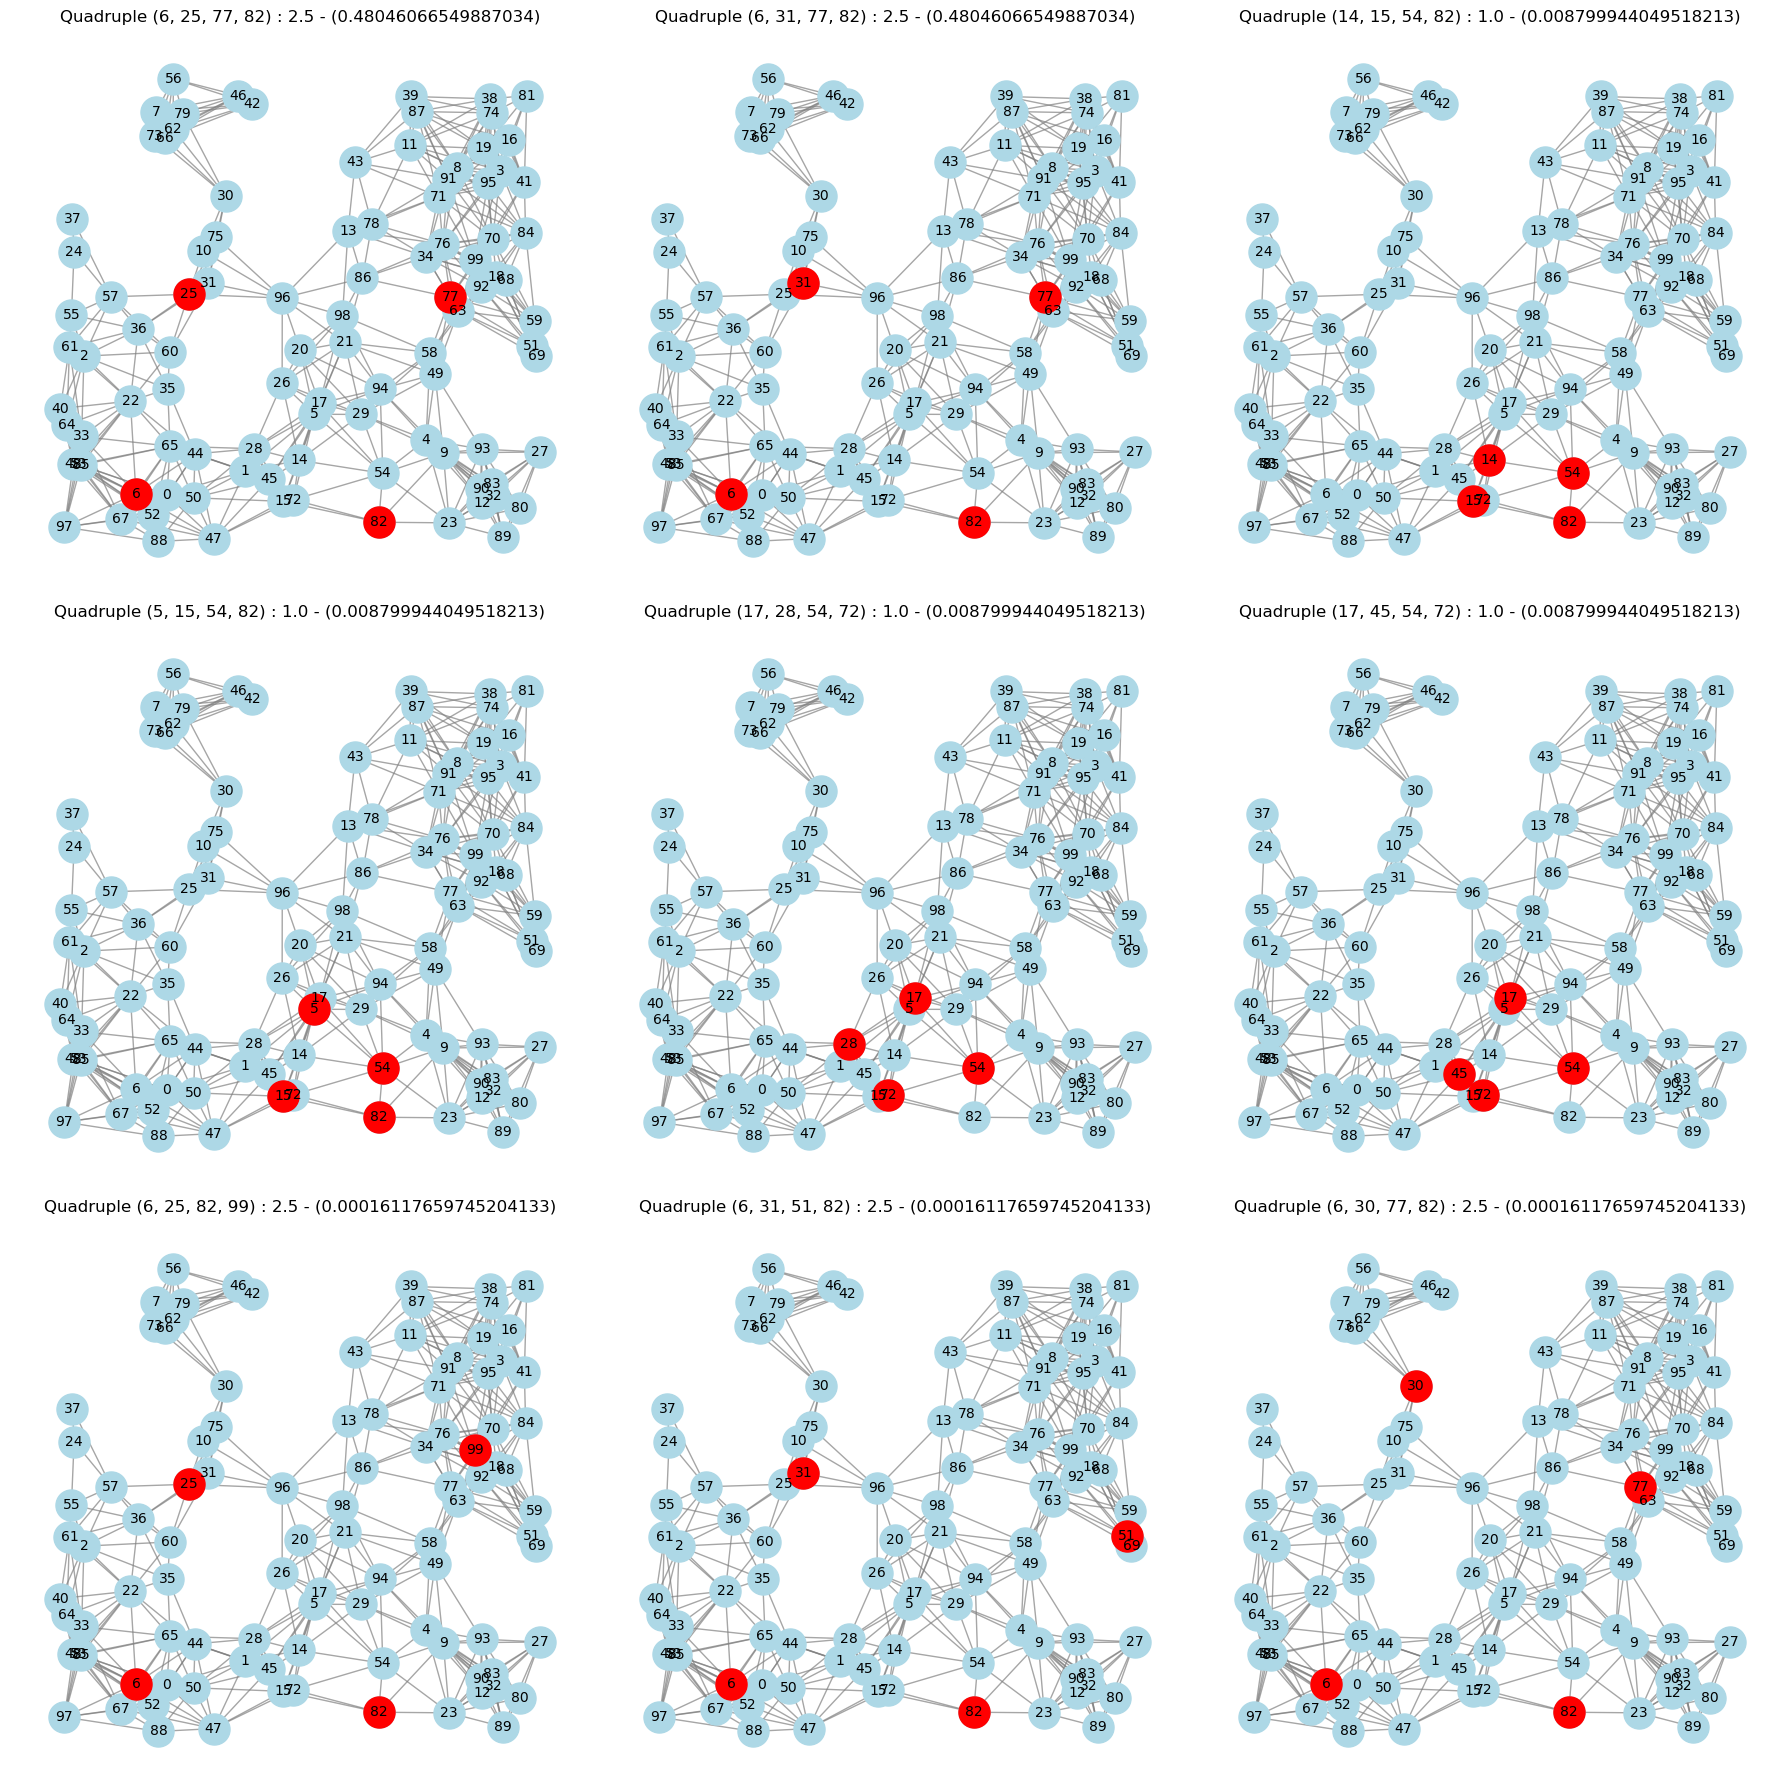

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (6, 25, 77, 82) : 2.5 - (0.48046066549887034)'}>,
        <Axes: title={'center': 'Quadruple (6, 31, 77, 82) : 2.5 - (0.48046066549887034)'}>,
        <Axes: title={'center': 'Quadruple (14, 15, 54, 82) : 1.0 - (0.008799944049518213)'}>,
        <Axes: title={'center': 'Quadruple (5, 15, 54, 82) : 1.0 - (0.008799944049518213)'}>,
        <Axes: title={'center': 'Quadruple (17, 28, 54, 72) : 1.0 - (0.008799944049518213)'}>,
        <Axes: title={'center': 'Quadruple (17, 45, 54, 72) : 1.0 - (0.008799944049518213)'}>,
        <Axes: title={'center': 'Quadruple (6, 25, 82, 99) : 2.5 - (0.00016117659745204133)'}>,
        <Axes: title={'center': 'Quadruple (6, 31, 51, 82) : 2.5 - (0.00016117659745204133)'}>,
        <Axes: title={'center': 'Quadruple (6, 30, 77, 82) : 2.5 - (0.00016117659745204133)'}>],
       dtype=object))

In [65]:
lambda_reg = 2

print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
real_gromov = E_gromov.copy()
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"The only data fidelity component mu times delta is: {np.sum(mu * real_gromov)}")
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

print(f"The distant sample nodes are: {distant_test_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, distant_test_nodes, dist_matrix)
real_gromov = E_gromov.copy()
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"The only data fidelity component mu times delta is: {np.sum(mu * real_gromov)}")
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

In [17]:
anchor = localized_nodes[0]

anchor_pos = np.array(pos[anchor])

# dictionary with the distances from the "anchor"
distances = {}

for node in G.nodes():
    p = np.array(pos[node])
    distances[node] = np.linalg.norm(p - anchor_pos)

In [18]:
sorted_dict = dict(sorted(distances.items(), key=lambda item: item[1], reverse=False))
print(sorted_dict)

{30: np.float64(0.0), 75: np.float64(0.09206674946122174), 10: np.float64(0.12847697717273068), 66: np.float64(0.17475161025925862), 62: np.float64(0.17823346445930582), 31: np.float64(0.1916665781024375), 73: np.float64(0.19259571927005312), 79: np.float64(0.19643722558272336), 42: np.float64(0.2038143938971634), 46: np.float64(0.21641479083990448), 25: np.float64(0.2253107812956965), 7: np.float64(0.22933530513806885), 96: np.float64(0.24903207834579316), 13: np.float64(0.2610973130138427), 56: np.float64(0.2724842867169028), 43: np.float64(0.2740332821665926), 78: np.float64(0.3050589659405942), 37: np.float64(0.31693288107954676), 57: np.float64(0.3192849369572874), 86: np.float64(0.3311069634444796), 24: np.float64(0.33217176985883223), 36: np.float64(0.3386560072689141), 98: np.float64(0.3515369832680626), 60: np.float64(0.35510577426656), 20: np.float64(0.36627272199653393), 11: np.float64(0.39118360211086933), 21: np.float64(0.3985991958683573), 55: np.float64(0.406033369674074

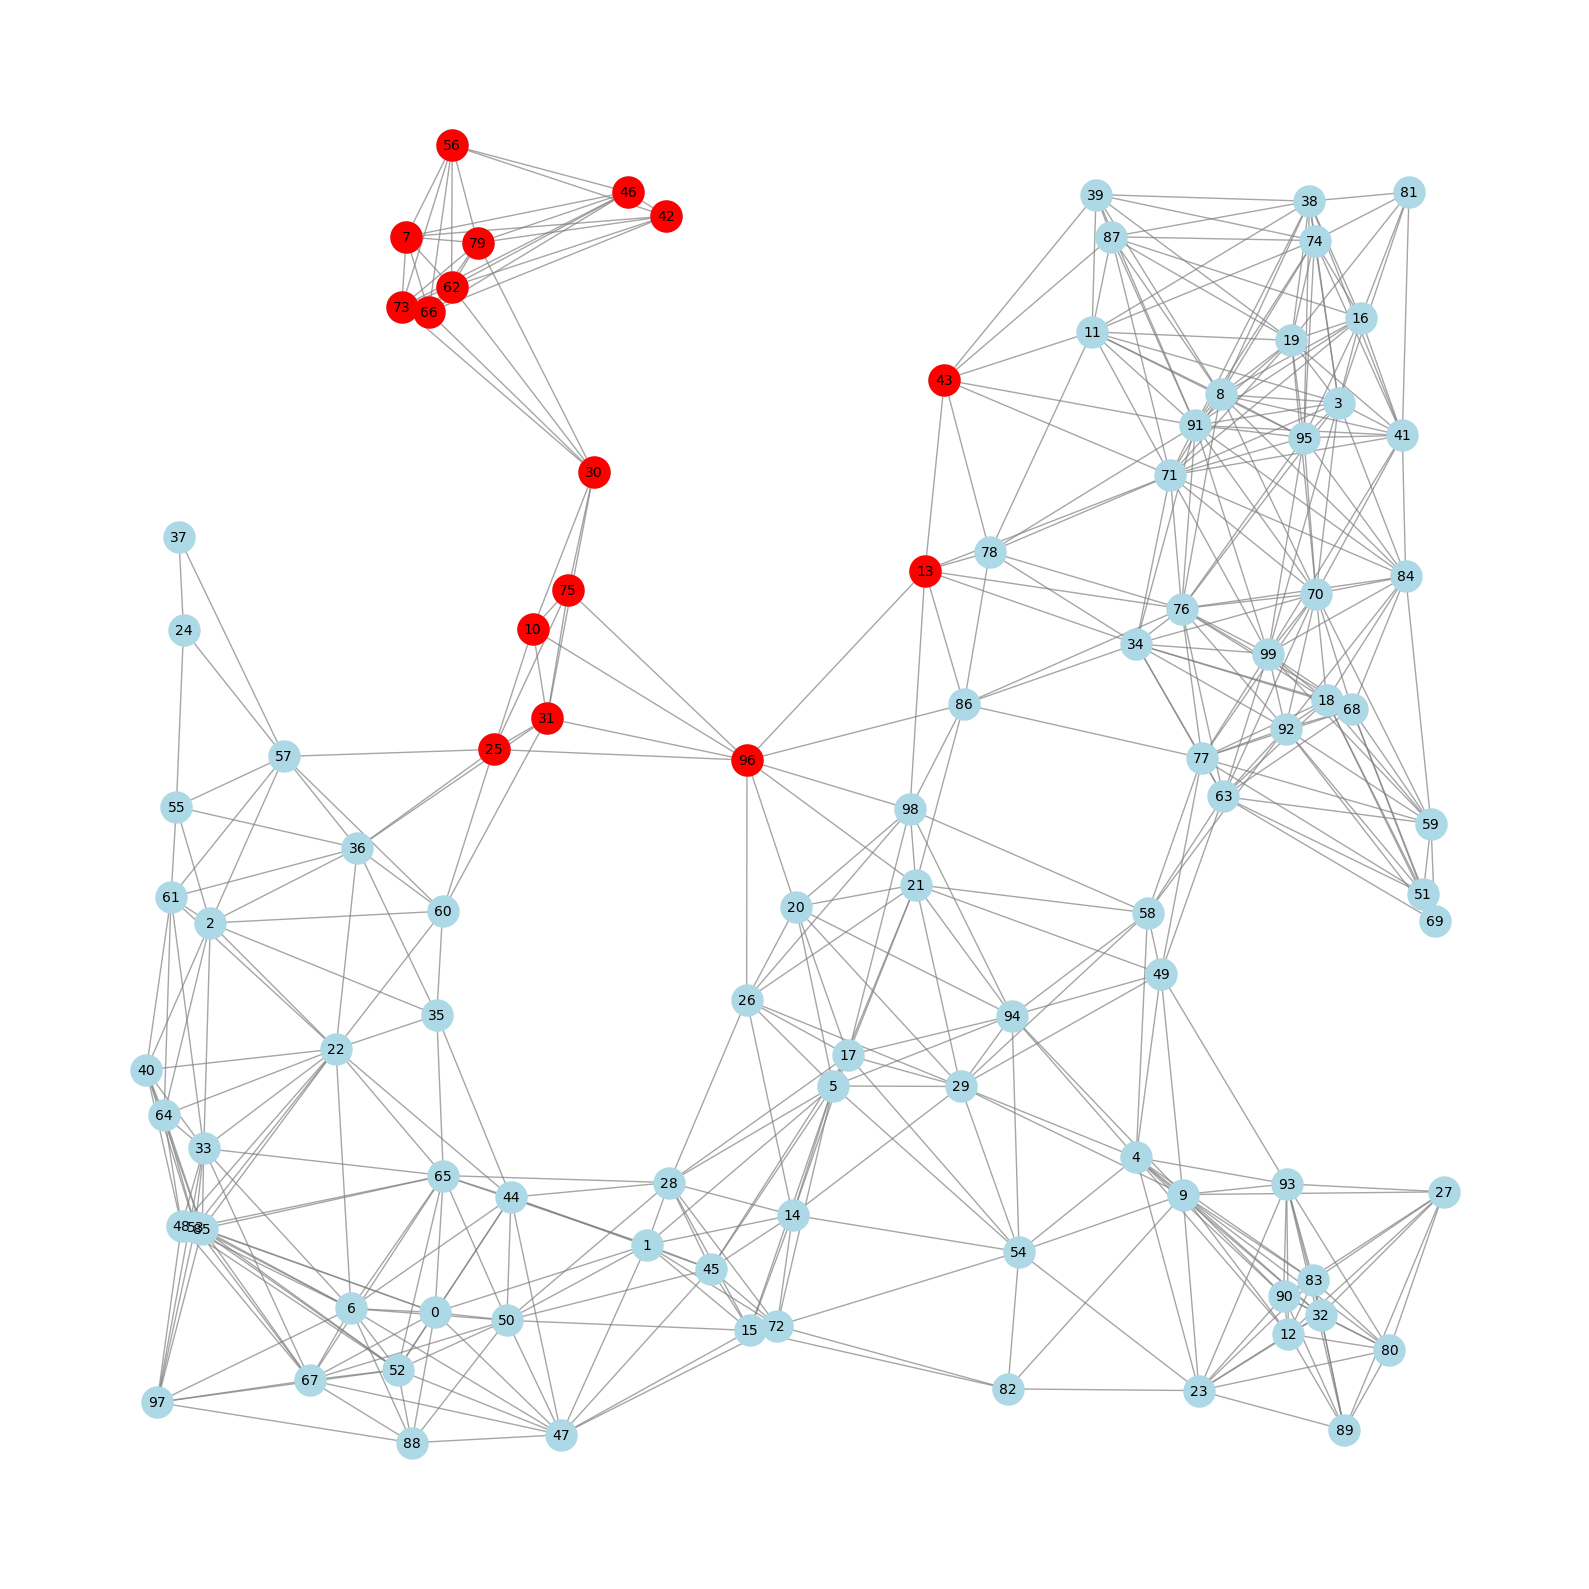

(<Figure size 1600x1600 with 1 Axes>, [<Axes: >])

In [22]:
safe_radius = 0.28

far_nodes = [
    node for node, d in distances.items()
    if d > safe_radius
]

close_nodes = [
    node for node, d in distances.items()
    if d <= safe_radius
]

draw_graphs(G,pos,highlight_nodes=close_nodes, base_figsize=(16,16))

In [74]:
import random
lambda_reg = 2
local_gromov = []
distant_gromov = []
global_gromov = []
not_local_gromov = []
not_distant_gromov = []
G_current = G.copy()


random.seed(42)
np.random.seed(42)
G_current = G.copy()

p = 0.5
n_steps = 300
far_nodes_list = list(far_nodes)

for k in range(0,n_steps+1):

    G_new = G_current.copy()

    if random.random() < p:
        # add
        u, v = random.sample(far_nodes_list, 2)
        if not G_new.has_edge(u, v):
            G_new.add_edge(u, v)

    else:
        # remove (solo se non disconnette)
        edges = [(u, v) for u, v in G_new.edges()
                 if u in far_nodes and v in far_nodes]

        random.shuffle(edges)

        removed = False
        for u, v in edges:
            G_temp = G_new.copy()
            G_temp.remove_edge(u, v)

            if nx.is_connected(G_temp):
                G_new = G_temp
                removed = True
                break

        # se nessun edge removibile mantiene connettività → non fai nulla

    G_current = G_new

    if(k % 20 == 0):
        print(f"step: {k}")
        dist_matrix = compute_distance_nodes(G_current)
        quads = list(itertools.combinations(list(G_current.nodes()), 4))
        E_gromov = gromov_energy(quads, dist_matrix)
        W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
        real_gromov = E_gromov.copy()
        E_gromov = normalize(E_gromov)
        W_local = normalize(W_local)

        cost_vector = E_gromov - lambda_reg * W_local

        mu = solve_entropic_regularization(cost_vector, temperature)

        first_term = mu * cost_vector
        second_term = temperature * mu * np.log(mu)
        cost_function_val = np.sum(first_term - second_term)
        print(f"The only data fidelity component mu times delta is: {np.sum(mu * real_gromov)}")
        print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

        local_gromov.append(cost_function_val)
        not_local_gromov.append(np.sum(mu * real_gromov))
        global_gromov.append(np.max(real_gromov))


        print(f"The distant sample nodes are: {distant_test_nodes} and lambda is {lambda_reg}")
        E_gromov = gromov_energy(quads, dist_matrix)
        W_local = local_weights_distance_based(quads, distant_test_nodes, dist_matrix)
        real_gromov = E_gromov.copy()
        E_gromov = normalize(E_gromov)
        W_local = normalize(W_local)

        cost_vector = E_gromov - lambda_reg * W_local

        mu = solve_entropic_regularization(cost_vector, temperature)

        first_term = mu * cost_vector
        second_term = temperature * mu * np.log(mu)
        cost_function_val = np.sum(first_term - second_term)
        print(f"The only data fidelity component mu times delta is: {np.sum(mu * real_gromov)}")
        print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

        distant_gromov.append(cost_function_val)
        not_distant_gromov.append(np.sum(mu * real_gromov))
   



step: 0
The only data fidelity component mu times delta is: 0.5006885967336214
La cost function e' 0.10469519043992732 - -0.033033464895584924: 0.13772865533551223
The distant sample nodes are: [54] and lambda is 2
The only data fidelity component mu times delta is: 2.4463561742252757
La cost function e' 0.3582745446462723 - -0.009055554509002584: 0.3673300991552749
step: 20
The only data fidelity component mu times delta is: 0.49995120941006277
La cost function e' 0.09471455524696049 - -0.032982870362490604: 0.12769742560945108
The distant sample nodes are: [54] and lambda is 2
The only data fidelity component mu times delta is: 2.003347861193931
La cost function e' 0.3993694859145003 - -0.007686617562299157: 0.4070561034767995
step: 40
The only data fidelity component mu times delta is: 0.5271346109606387
La cost function e' 0.13837861304962545 - -0.03365189042071853: 0.172030503470344
The distant sample nodes are: [54] and lambda is 2
The only data fidelity component mu times delta 

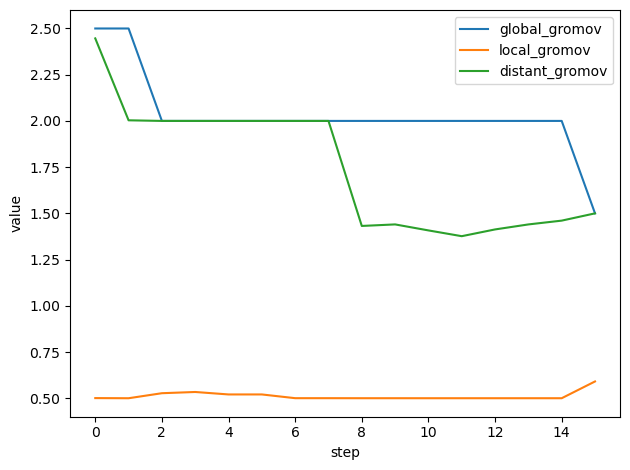

In [75]:
plt.figure()

plt.plot(global_gromov, label="global_gromov")
plt.plot(not_local_gromov, label="local_gromov")
plt.plot(not_distant_gromov, label="distant_gromov")

plt.xlabel("step")
plt.ylabel("value")
plt.legend()
plt.tight_layout()

plt.show()

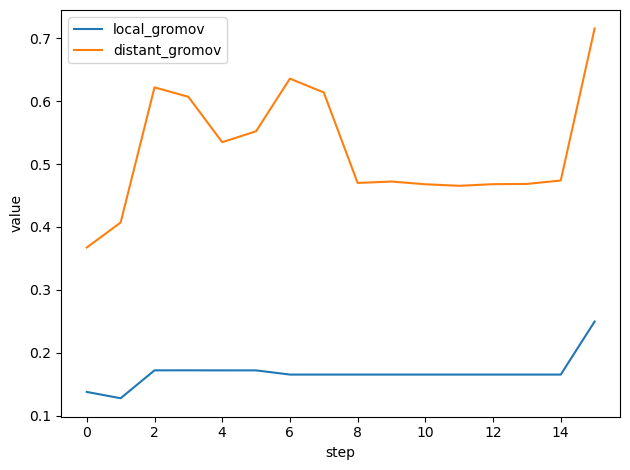

In [76]:
plt.figure()


plt.plot(local_gromov, label="local_gromov")
plt.plot(distant_gromov, label="distant_gromov")

plt.xlabel("step")
plt.ylabel("value")
plt.legend()
plt.tight_layout()

plt.show()

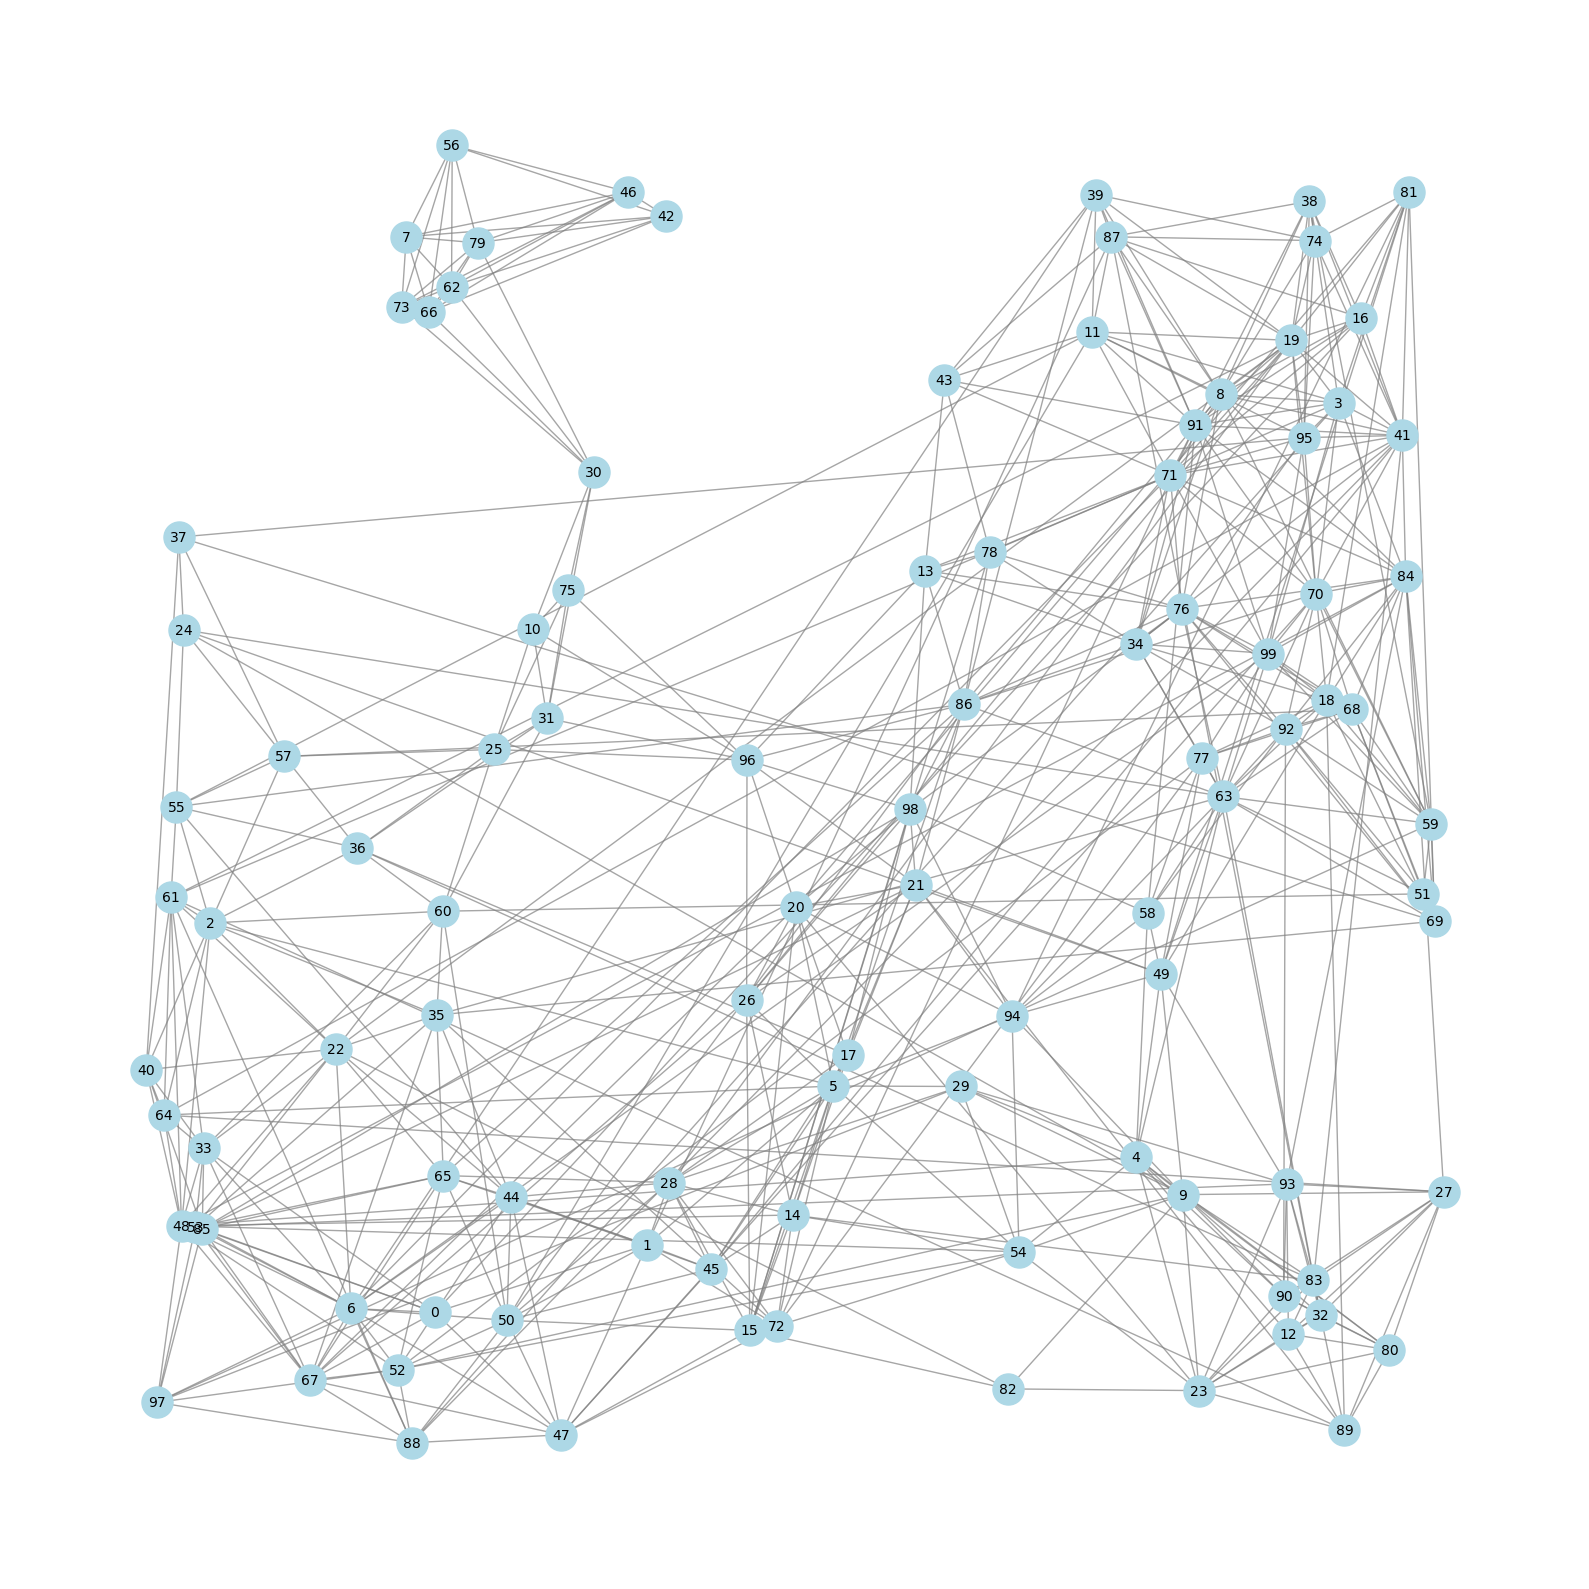

(<Figure size 1600x1600 with 1 Axes>, [<Axes: >])

In [61]:
draw_graphs(G_current,pos, base_figsize=(16,16))

In [62]:
delta_max, quads = compute_gromov_hyperbolicity(G_current)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

Counter({np.float64(0.0): 1923070, np.float64(0.5): 1748405, np.float64(1.0): 246324, np.float64(1.5): 3414, np.float64(2.0): 12})


The localized nodes are: [30] and lambda is 2
The only data fidelity component mu times delta is: 0.5006885967336214
La cost function e' 0.10469519043992732 - -0.033033464895584924: 0.13772865533551223


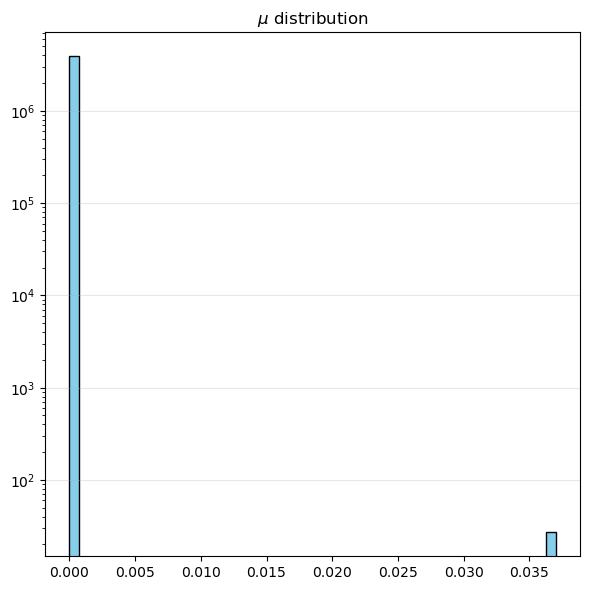

Too many quadruples to visualize (10), showing only the first 9.


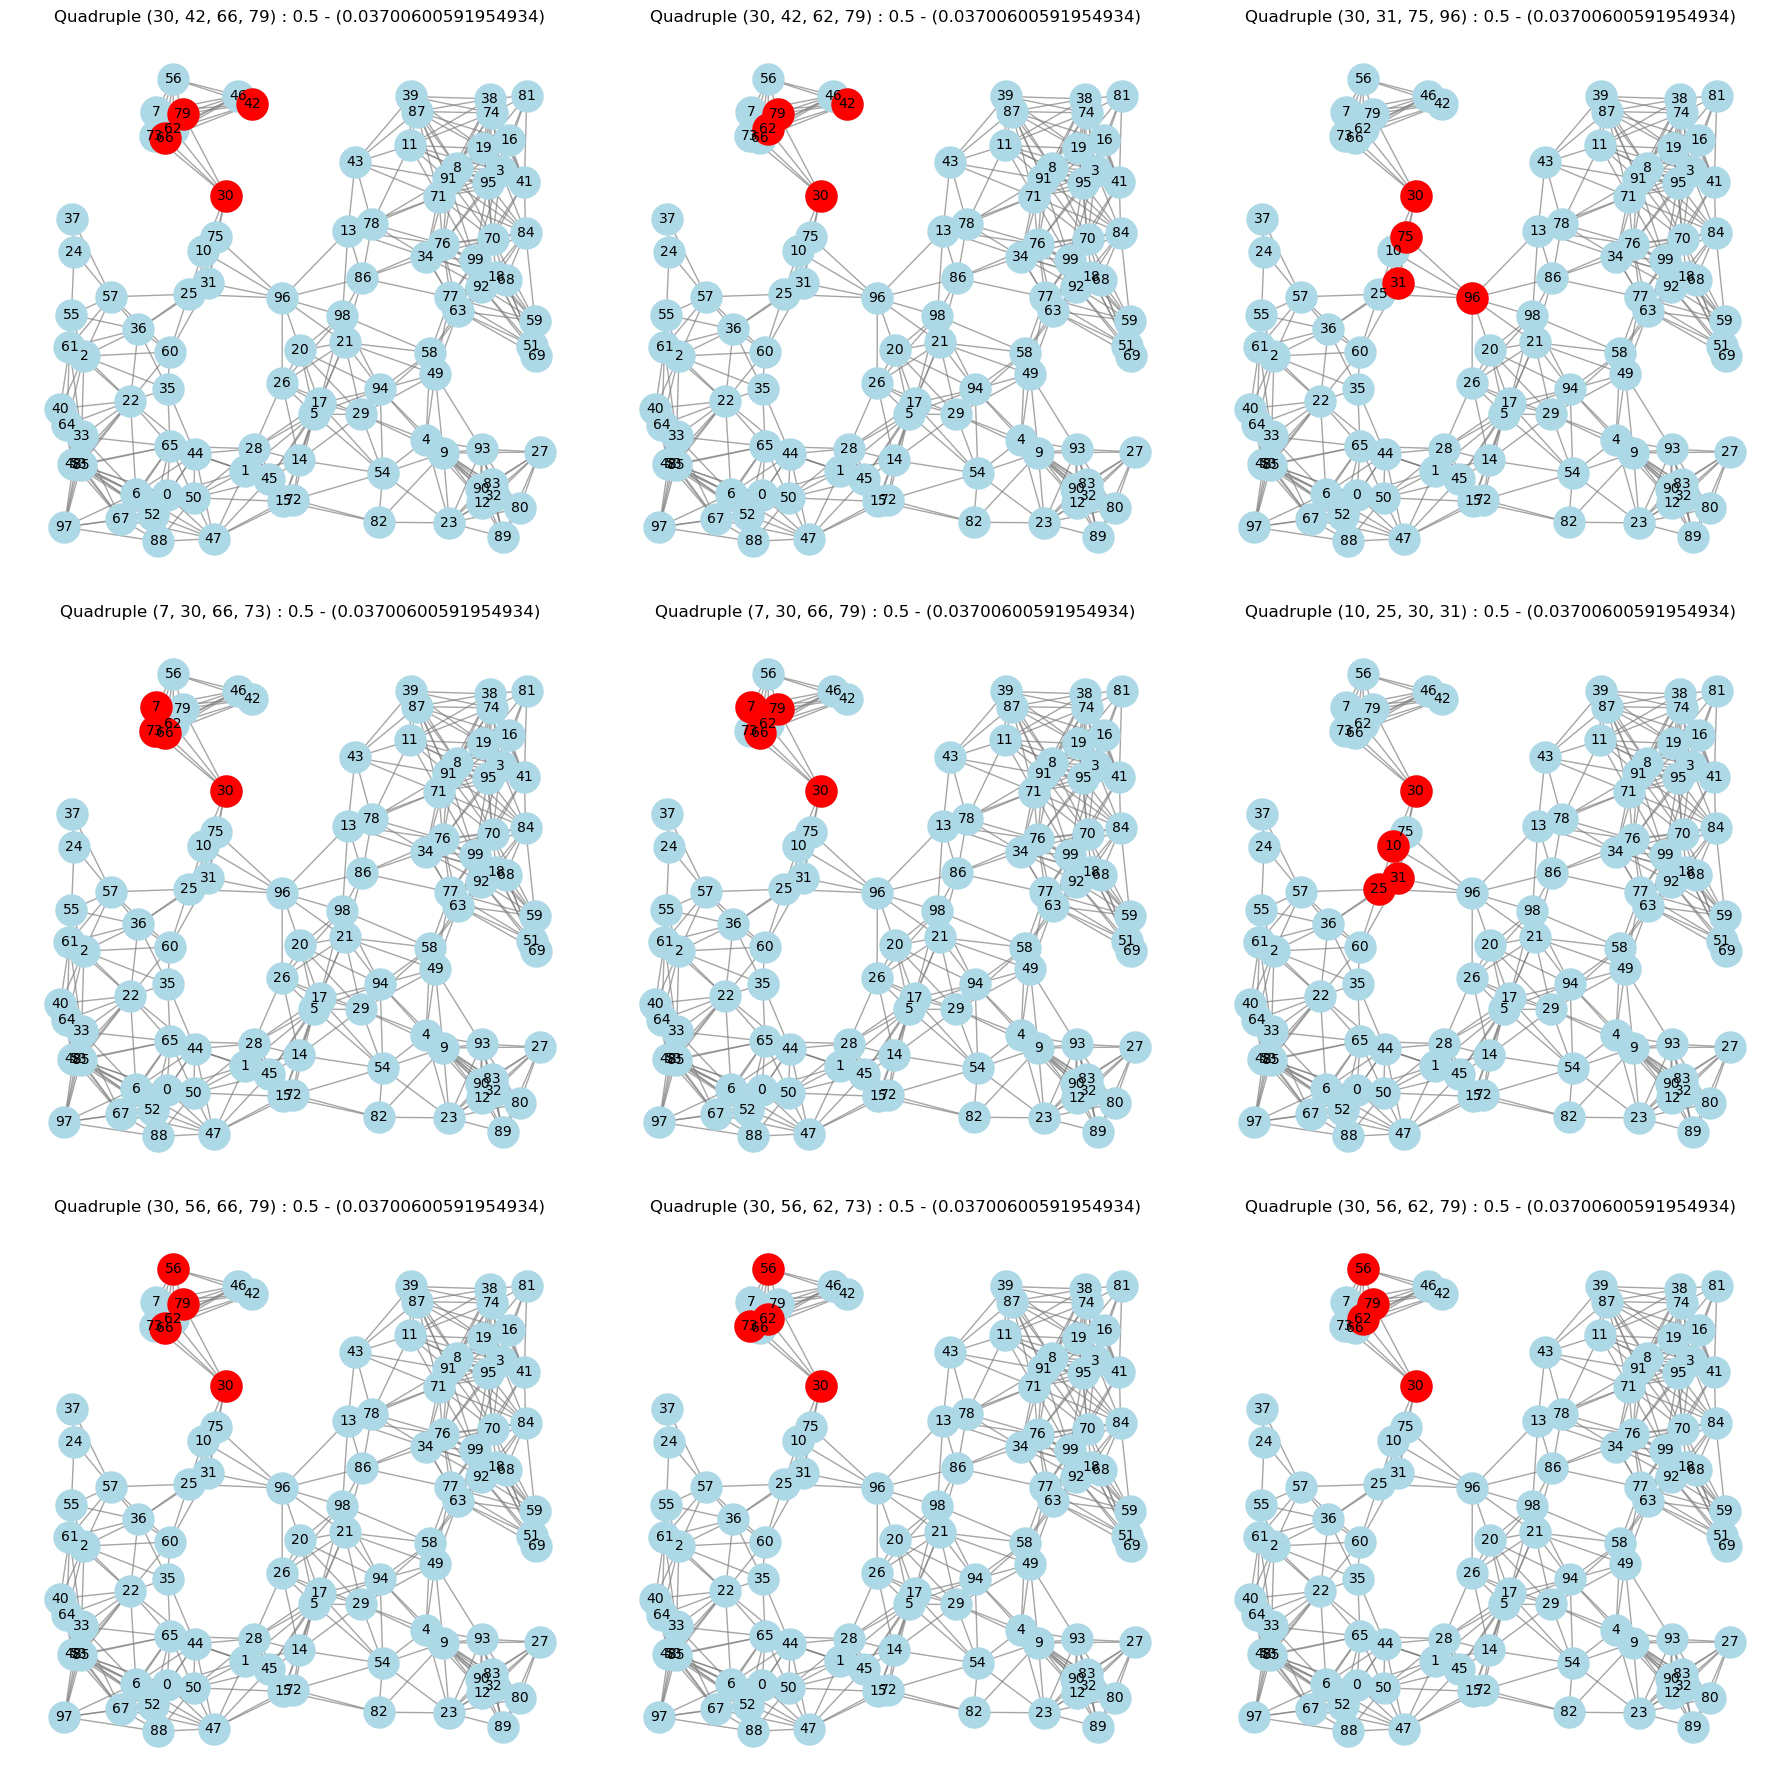

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (30, 42, 66, 79) : 0.5 - (0.03700600591954934)'}>,
        <Axes: title={'center': 'Quadruple (30, 42, 62, 79) : 0.5 - (0.03700600591954934)'}>,
        <Axes: title={'center': 'Quadruple (30, 31, 75, 96) : 0.5 - (0.03700600591954934)'}>,
        <Axes: title={'center': 'Quadruple (7, 30, 66, 73) : 0.5 - (0.03700600591954934)'}>,
        <Axes: title={'center': 'Quadruple (7, 30, 66, 79) : 0.5 - (0.03700600591954934)'}>,
        <Axes: title={'center': 'Quadruple (10, 25, 30, 31) : 0.5 - (0.03700600591954934)'}>,
        <Axes: title={'center': 'Quadruple (30, 56, 66, 79) : 0.5 - (0.03700600591954934)'}>,
        <Axes: title={'center': 'Quadruple (30, 56, 62, 73) : 0.5 - (0.03700600591954934)'}>,
        <Axes: title={'center': 'Quadruple (30, 56, 62, 79) : 0.5 - (0.03700600591954934)'}>],
       dtype=object))

In [63]:
lambda_reg = 2
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
real_gromov = E_gromov.copy()
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"The only data fidelity component mu times delta is: {np.sum(mu * real_gromov)}")
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)